# MSFT Verisi - Kronolojik Train, Validation ve Test Ayrımı

Bu notebook'un ilk amacı, MSFT kapanış fiyatı serisini zaman sırasını bozmadan üç döneme ayırmaktır. Bu aşamada ölçekleme, kayan pencere veya PyTorch tensorları oluşturulmaz.

**Ayrım oranları:**

- Train: ilk `%70`
- Validation: sonraki `%15`
- Test: son `%15`

Rastgele ayrım kullanılmaz; geçmiş verilerle daha yeni dönemleri tahmin etme koşulu korunur.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Kapanış fiyatı serisini yükleme

İlk model yalnızca düzeltilmiş `Close` fiyatını kullanacaktır. Diğer OHLCV alanları ham veride korunur, ancak bu notebook'taki ayrım hesabına dahil edilmez.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("Ham veri bulunamadı. Önce `uv run download-msft-data` çalıştırın.")

print(f"Veri dosyası: {DATA_PATH}")

Veri dosyası: C:\Users\brkbs\Desktop\Stock_Price_Prediction\data\raw\msft_daily_latest.csv


In [3]:
data = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date").sort_index()
close_prices = data[["Close"]].copy()

assert close_prices.index.is_monotonic_increasing
assert not close_prices.index.has_duplicates
assert not close_prices.isna().any().any()

print(f"Toplam gözlem: {len(close_prices):,}")
print(f"Tarih aralığı: {close_prices.index.min().date()} - {close_prices.index.max().date()}")
display(close_prices.head())

Toplam gözlem: 4,156
Tarih aralığı: 2010-01-04 - 2026-07-14


,Close
Date,
2010-01-04,23.0275
2010-01-05,23.0349
2010-01-06,22.8936
2010-01-07,22.6555
2010-01-08,22.8117


## 2. Kronolojik ayrım

Sınırlar gözlem sayısına göre hesaplanır. İlk `%70` train, sonraki `%15` validation ve kalan gözlemler test dönemine atanır. Kesirli sonuçlar aşağı yuvarlandığı için kalan bir gözlem varsa test setinde tutulur.

In [4]:
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15

train_end = int(len(close_prices) * TRAIN_RATIO)
validation_end = train_end + int(len(close_prices) * VALIDATION_RATIO)

train_data = close_prices.iloc[:train_end].copy()
validation_data = close_prices.iloc[train_end:validation_end].copy()
test_data = close_prices.iloc[validation_end:].copy()

print(f"Train sınır indeksi: {train_end:,}")
print(f"Validation sınır indeksi: {validation_end:,}")

Train sınır indeksi: 2,909
Validation sınır indeksi: 3,532


In [5]:
split_summary = pd.DataFrame(
    {
        "Gözlem": [len(train_data), len(validation_data), len(test_data)],
        "Oran (%)": [
            len(train_data) / len(close_prices) * 100,
            len(validation_data) / len(close_prices) * 100,
            len(test_data) / len(close_prices) * 100,
        ],
        "Başlangıç": [
            train_data.index.min().date(),
            validation_data.index.min().date(),
            test_data.index.min().date(),
        ],
        "Bitiş": [
            train_data.index.max().date(),
            validation_data.index.max().date(),
            test_data.index.max().date(),
        ],
    },
    index=["Train", "Validation", "Test"],
)

split_summary

,Gözlem,Oran (%),Başlangıç,Bitiş
Train,2909,69.9952,2010-01-04,2021-07-23
Validation,623,14.9904,2021-07-26,2024-01-16
Test,624,15.0144,2024-01-17,2026-07-14


## 3. Ayrımın doğrulanması

Aşağıdaki kontroller üç bölümün boş olmadığını, doğru sırada bulunduğunu, kesişmediğini ve yeniden birleştirildiğinde orijinal seriyi eksiksiz oluşturduğunu doğrular.

In [6]:
assert len(train_data) > 0
assert len(validation_data) > 0
assert len(test_data) > 0

assert train_data.index.max() < validation_data.index.min()
assert validation_data.index.max() < test_data.index.min()

recombined = pd.concat([train_data, validation_data, test_data])
pd.testing.assert_frame_equal(recombined, close_prices)

assert train_data.index.intersection(validation_data.index).empty
assert train_data.index.intersection(test_data.index).empty
assert validation_data.index.intersection(test_data.index).empty

print("Ayrım kontrolleri başarılı: sıra doğru, çakışma ve kayıp gözlem yok.")

Ayrım kontrolleri başarılı: sıra doğru, çakışma ve kayıp gözlem yok.


## 4. Dönemlerin görselleştirilmesi

Her bölüm farklı renkle çizilir. Model train döneminden öğrenecek, validation dönemi model seçiminde kullanılacak ve test dönemi yalnızca nihai değerlendirmede açılacaktır.

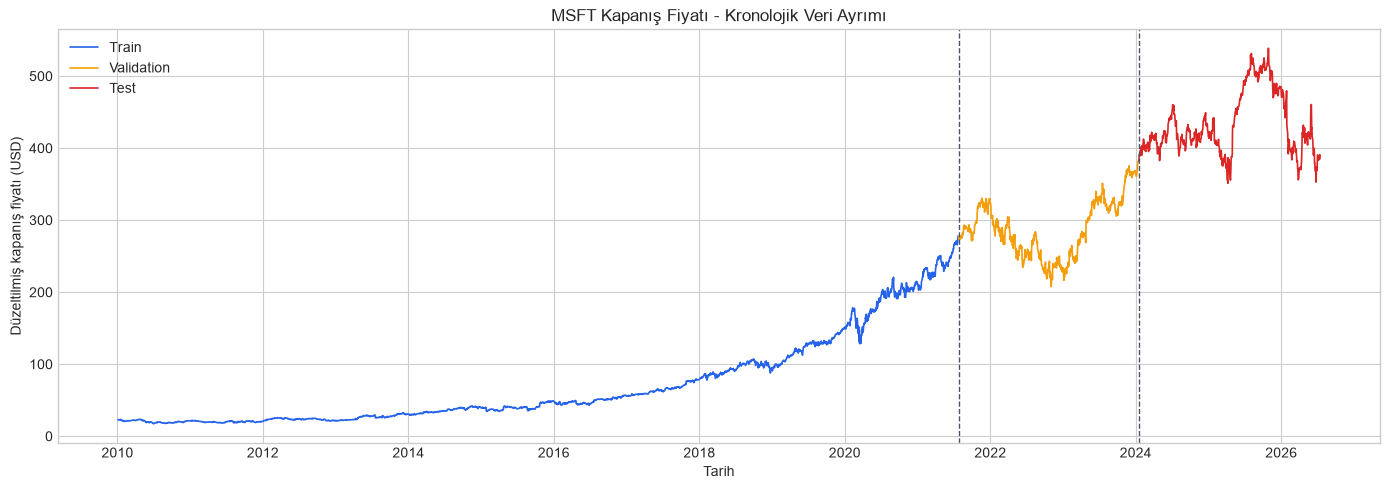

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_data.index, train_data["Close"], label="Train", color="#2563EB", linewidth=1.2)
ax.plot(
    validation_data.index,
    validation_data["Close"],
    label="Validation",
    color="#F59E0B",
    linewidth=1.2,
)
ax.plot(test_data.index, test_data["Close"], label="Test", color="#DC2626", linewidth=1.2)

ax.axvline(validation_data.index.min(), color="#475569", linestyle="--", linewidth=1)
ax.axvline(test_data.index.min(), color="#475569", linestyle="--", linewidth=1)
ax.set(
    title="MSFT Kapanış Fiyatı - Kronolojik Veri Ayrımı",
    xlabel="Tarih",
    ylabel="Düzeltilmiş kapanış fiyatı (USD)",
)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Train verisine göre MinMax ölçekleme

LSTM ve GRU eğitiminde büyük fiyat değerleri yerine kontrollü bir sayısal aralık kullanmak optimizasyonu kolaylaştırır. PDF'deki başlangıç yaklaşımına uygun olarak fiyatlar `[-1, 1]` aralığına ölçeklenir.

Scaler yalnızca train döneminin minimum ve maksimum fiyatlarını öğrenir. Validation ve test dönemleri `fit` edilmez; aynı train dönüşümüyle yalnızca `transform` edilir. Böylece gelecekteki fiyat seviyeleri eğitim sürecine sızmaz.

In [8]:
scaler = MinMaxScaler(feature_range=(-1, 1))

train_scaled = pd.DataFrame(
    scaler.fit_transform(train_data),
    index=train_data.index,
    columns=["Close_Scaled"],
)
validation_scaled = pd.DataFrame(
    scaler.transform(validation_data),
    index=validation_data.index,
    columns=["Close_Scaled"],
)
test_scaled = pd.DataFrame(
    scaler.transform(test_data),
    index=test_data.index,
    columns=["Close_Scaled"],
)

scaler_summary = pd.Series(
    {
        "Fit edilen gözlem sayısı": scaler.n_samples_seen_,
        "Train minimum fiyatı": scaler.data_min_[0],
        "Train maksimum fiyatı": scaler.data_max_[0],
        "Öğrenilen fiyat aralığı": scaler.data_range_[0],
        "Hedef ölçek alt sınırı": scaler.feature_range[0],
        "Hedef ölçek üst sınırı": scaler.feature_range[1],
    },
    name="Değer",
)
scaler_summary.to_frame()

,Değer
Fit edilen gözlem sayısı,"2,909.0000"
Train minimum fiyatı,17.2776
Train maksimum fiyatı,277.9953
Öğrenilen fiyat aralığı,260.7176
Hedef ölçek alt sınırı,-1.0000
Hedef ölçek üst sınırı,1.0000


In [9]:
scaled_range_summary = pd.DataFrame(
    {
        "Orijinal minimum": [
            train_data["Close"].min(),
            validation_data["Close"].min(),
            test_data["Close"].min(),
        ],
        "Orijinal maksimum": [
            train_data["Close"].max(),
            validation_data["Close"].max(),
            test_data["Close"].max(),
        ],
        "Ölçeklenmiş minimum": [
            train_scaled["Close_Scaled"].min(),
            validation_scaled["Close_Scaled"].min(),
            test_scaled["Close_Scaled"].min(),
        ],
        "Ölçeklenmiş maksimum": [
            train_scaled["Close_Scaled"].max(),
            validation_scaled["Close_Scaled"].max(),
            test_scaled["Close_Scaled"].max(),
        ],
    },
    index=["Train", "Validation", "Test"],
)

scaled_range_summary

,Orijinal minimum,Orijinal maksimum,Ölçeklenmiş minimum,Ölçeklenmiş maksimum
Train,17.2776,277.9953,-1.0000,1.0000
Validation,207.7340,382.8317,0.4610,1.8042
Test,351.1058,538.6586,1.5608,2.9996


Validation veya test değerlerinin `[-1, 1]` dışına çıkması hata değildir. Bu durum, gelecekteki bir fiyatın train dönemindeki maksimumdan yüksek veya minimumdan düşük olduğunu gösterir. Bu değerleri zorla kırpmak bilgi kaybına yol açacağı için `clip=True` kullanılmaz.

In [10]:
assert scaler.n_samples_seen_ == len(train_data)
np.testing.assert_allclose(scaler.data_min_, train_data.min().to_numpy())
np.testing.assert_allclose(scaler.data_max_, train_data.max().to_numpy())

for original, scaled in [
    (train_data, train_scaled),
    (validation_data, validation_scaled),
    (test_data, test_scaled),
]:
    assert original.index.equals(scaled.index)
    reconstructed = scaler.inverse_transform(scaled)
    np.testing.assert_allclose(reconstructed, original.to_numpy(), rtol=1e-10, atol=1e-10)

print("Ölçekleme kontrolleri başarılı: scaler yalnızca train verisine fit edildi.")
print("Ters dönüşüm, üç veri bölümünde de orijinal fiyatları geri üretti.")

Ölçekleme kontrolleri başarılı: scaler yalnızca train verisine fit edildi.
Ters dönüşüm, üç veri bölümünde de orijinal fiyatları geri üretti.


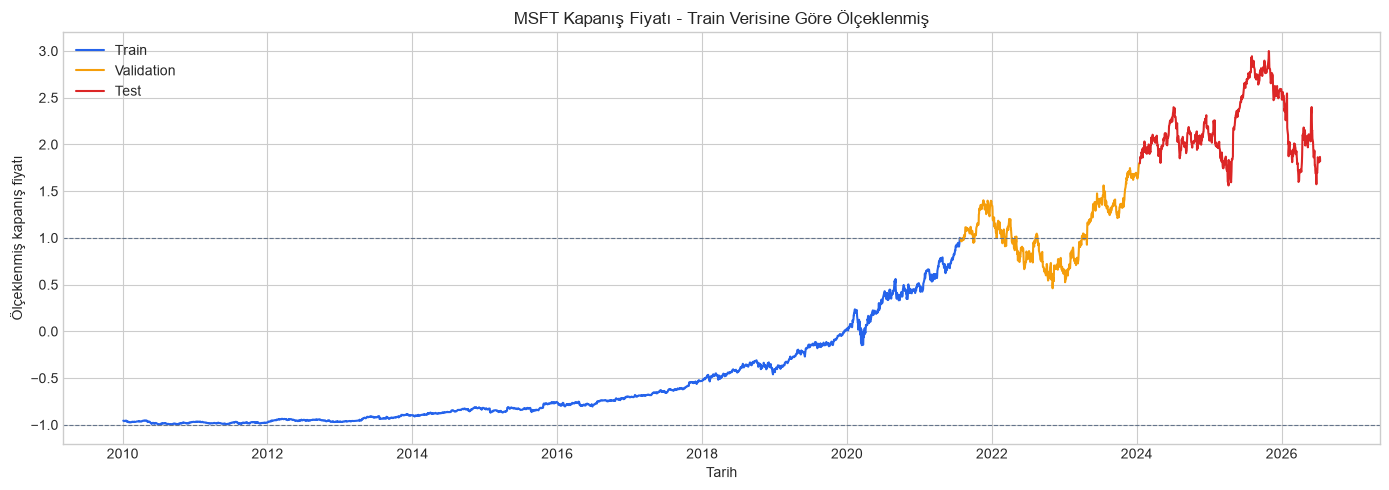

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_scaled.index, train_scaled["Close_Scaled"], label="Train", color="#2563EB")
ax.plot(
    validation_scaled.index,
    validation_scaled["Close_Scaled"],
    label="Validation",
    color="#F59E0B",
)
ax.plot(test_scaled.index, test_scaled["Close_Scaled"], label="Test", color="#DC2626")
ax.axhline(-1, color="#64748B", linestyle="--", linewidth=0.8)
ax.axhline(1, color="#64748B", linestyle="--", linewidth=0.8)
ax.set(
    title="MSFT Kapanış Fiyatı - Train Verisine Göre Ölçeklenmiş",
    xlabel="Tarih",
    ylabel="Ölçeklenmiş kapanış fiyatı",
)
ax.legend()
fig.tight_layout()
plt.show()

## 6. 20 günlük kayan pencereler

Her model örneği, hedef işlem gününden önceki 20 ölçeklenmiş kapanış fiyatını girdi (`X`) ve hedef günün ölçeklenmiş kapanış fiyatını çıktı (`y`) olarak kullanır.

Bir örneğin train, validation veya test setine ait olması **hedef tarihine** göre belirlenir. Validation'ın ilk hedefi için train döneminin son 20 günü, testin ilk hedefi için validation döneminin son 20 günü geçmiş bağlamı olarak kullanılabilir. Bu kullanım gelecekteki hedefleri geçmişe taşımaz.

In [12]:
LOOKBACK = 20
full_scaled = pd.concat([train_scaled, validation_scaled, test_scaled])
pd.testing.assert_index_equal(full_scaled.index, close_prices.index)


def create_sequences(scaled_data, target_index, lookback):
    """Create sequences whose membership is determined by the target date."""
    values = scaled_data.to_numpy(dtype=np.float32)
    allowed_targets = set(target_index)
    inputs = []
    targets = []
    target_dates = []

    for target_position in range(lookback, len(scaled_data)):
        target_date = scaled_data.index[target_position]
        if target_date not in allowed_targets:
            continue

        inputs.append(values[target_position - lookback : target_position])
        targets.append(values[target_position])
        target_dates.append(target_date)

    if not inputs:
        raise ValueError("Hedef tarihleri için pencere oluşturulamadı.")

    return (
        np.stack(inputs),
        np.stack(targets),
        pd.DatetimeIndex(target_dates, name="Date"),
    )

In [13]:
X_train, y_train, train_target_dates = create_sequences(
    full_scaled, train_data.index, LOOKBACK
)
X_validation, y_validation, validation_target_dates = create_sequences(
    full_scaled, validation_data.index, LOOKBACK
)
X_test, y_test, test_target_dates = create_sequences(
    full_scaled, test_data.index, LOOKBACK
)

In [14]:
window_summary = pd.DataFrame(
    {
        "Örnek sayısı": [len(X_train), len(X_validation), len(X_test)],
        "X şekli": [str(X_train.shape), str(X_validation.shape), str(X_test.shape)],
        "y şekli": [str(y_train.shape), str(y_validation.shape), str(y_test.shape)],
        "İlk hedef tarihi": [
            train_target_dates.min().date(),
            validation_target_dates.min().date(),
            test_target_dates.min().date(),
        ],
        "Son hedef tarihi": [
            train_target_dates.max().date(),
            validation_target_dates.max().date(),
            test_target_dates.max().date(),
        ],
    },
    index=["Train", "Validation", "Test"],
)

window_summary

,Örnek sayısı,X şekli,y şekli,İlk hedef tarihi,Son hedef tarihi
Train,2889,"(2889, 20, 1)","(2889, 1)",2010-02-02,2021-07-23
Validation,623,"(623, 20, 1)","(623, 1)",2021-07-26,2024-01-16
Test,624,"(624, 20, 1)","(624, 1)",2024-01-17,2026-07-14


Train setinin ilk 20 günü, kendilerinden önce yeterli geçmiş bulunmadığı için hedef örneği oluşturmaz. Validation ve test başlangıçlarında ise önceki kronolojik bölümden 20 günlük geçmiş mevcut olduğundan bu dönemlerde hedef kaybı yaşanmaz.

In [15]:
assert X_train.shape == (len(train_data) - LOOKBACK, LOOKBACK, 1)
assert X_validation.shape == (len(validation_data), LOOKBACK, 1)
assert X_test.shape == (len(test_data), LOOKBACK, 1)
assert y_train.shape == (len(X_train), 1)
assert y_validation.shape == (len(X_validation), 1)
assert y_test.shape == (len(X_test), 1)

assert train_target_dates[0] == train_data.index[LOOKBACK]
assert validation_target_dates[0] == validation_data.index[0]
assert test_target_dates[0] == test_data.index[0]

validation_start_position = full_scaled.index.get_loc(validation_target_dates[0])
validation_context_dates = full_scaled.index[
    validation_start_position - LOOKBACK : validation_start_position
]
test_start_position = full_scaled.index.get_loc(test_target_dates[0])
test_context_dates = full_scaled.index[test_start_position - LOOKBACK : test_start_position]

pd.testing.assert_index_equal(validation_context_dates, train_data.index[-LOOKBACK:])
pd.testing.assert_index_equal(test_context_dates, validation_data.index[-LOOKBACK:])

assert set(train_target_dates).isdisjoint(validation_target_dates)
assert set(train_target_dates).isdisjoint(test_target_dates)
assert set(validation_target_dates).isdisjoint(test_target_dates)

np.testing.assert_allclose(
    y_validation[:, 0], full_scaled.loc[validation_target_dates, "Close_Scaled"]
)
np.testing.assert_allclose(y_test[:, 0], full_scaled.loc[test_target_dates, "Close_Scaled"])

print("Pencere kontrolleri başarılı: şekiller ve hedef tarihleri doğru.")
print("Validation/test başlangıçları önceki dönemin son 20 gününü bağlam olarak kullanıyor.")

Pencere kontrolleri başarılı: şekiller ve hedef tarihleri doğru.
Validation/test başlangıçları önceki dönemin son 20 gününü bağlam olarak kullanıyor.


In [16]:
first_validation_target_date = validation_target_dates[0]
example_dates = validation_context_dates.append(
    pd.DatetimeIndex([first_validation_target_date])
)
example_window = pd.DataFrame(
    {
        "Rol": [f"Girdi {step}" for step in range(1, LOOKBACK + 1)] + ["Hedef"],
        "Close": close_prices.loc[example_dates, "Close"].to_numpy(),
        "Close_Scaled": full_scaled.loc[example_dates, "Close_Scaled"].to_numpy(),
    },
    index=example_dates,
)
example_window.index.name = "Date"
example_window.tail()

,Rol,Close,Close_Scaled
Date,,,
2021-07-20,Girdi 17,268.0625,0.9238
2021-07-21,Girdi 18,270.0586,0.9391
2021-07-22,Girdi 19,274.6076,0.9740
2021-07-23,Girdi 20,277.9953,1.0000
2021-07-26,Hedef,277.4003,0.9954


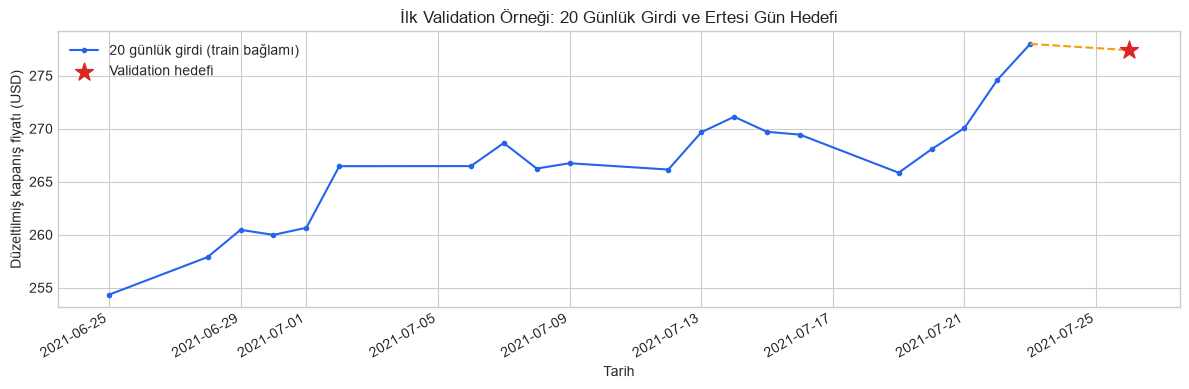

In [17]:
context_prices = close_prices.loc[validation_context_dates, "Close"]
target_price = close_prices.loc[first_validation_target_date, "Close"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    context_prices.index,
    context_prices,
    marker="o",
    markersize=3,
    color="#2563EB",
    label="20 günlük girdi (train bağlamı)",
)
ax.plot(
    [context_prices.index[-1], first_validation_target_date],
    [context_prices.iloc[-1], target_price],
    color="#F59E0B",
    linestyle="--",
)
ax.scatter(
    first_validation_target_date,
    target_price,
    marker="*",
    s=180,
    color="#DC2626",
    label="Validation hedefi",
    zorder=3,
)
ax.set(
    title="İlk Validation Örneği: 20 Günlük Girdi ve Ertesi Gün Hedefi",
    xlabel="Tarih",
    ylabel="Düzeltilmiş kapanış fiyatı (USD)",
)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7. PyTorch tensorlarına dönüştürme

PyTorch modelleri NumPy dizileri yerine tensorlarla çalışır. `torch.from_numpy` mevcut `float32` dizilerini kopyalamadan tensor görünümüne dönüştürür. Girdi düzeni `[örnek, zaman adımı, özellik]`, hedef düzeni `[örnek, çıktı]` olarak korunur.

In [18]:
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_validation_tensor = torch.from_numpy(X_validation)
y_validation_tensor = torch.from_numpy(y_validation)
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

In [19]:
tensor_summary = pd.DataFrame(
    {
        "X şekli": [
            str(tuple(X_train_tensor.shape)),
            str(tuple(X_validation_tensor.shape)),
            str(tuple(X_test_tensor.shape)),
        ],
        "y şekli": [
            str(tuple(y_train_tensor.shape)),
            str(tuple(y_validation_tensor.shape)),
            str(tuple(y_test_tensor.shape)),
        ],
        "X dtype": [
            str(X_train_tensor.dtype),
            str(X_validation_tensor.dtype),
            str(X_test_tensor.dtype),
        ],
        "y dtype": [
            str(y_train_tensor.dtype),
            str(y_validation_tensor.dtype),
            str(y_test_tensor.dtype),
        ],
        "Cihaz": [
            str(X_train_tensor.device),
            str(X_validation_tensor.device),
            str(X_test_tensor.device),
        ],
    },
    index=["Train", "Validation", "Test"],
)

tensor_summary

,X şekli,y şekli,X dtype,y dtype,Cihaz
Train,"(2889, 20, 1)","(2889, 1)",torch.float32,torch.float32,cpu
Validation,"(623, 20, 1)","(623, 1)",torch.float32,torch.float32,cpu
Test,"(624, 20, 1)","(624, 1)",torch.float32,torch.float32,cpu


In [20]:
tensor_pairs = [
    (X_train, y_train, X_train_tensor, y_train_tensor),
    (X_validation, y_validation, X_validation_tensor, y_validation_tensor),
    (X_test, y_test, X_test_tensor, y_test_tensor),
]

for X_array, y_array, X_tensor, y_tensor in tensor_pairs:
    assert X_tensor.dtype == torch.float32
    assert y_tensor.dtype == torch.float32
    assert X_tensor.ndim == 3
    assert X_tensor.shape[1:] == (LOOKBACK, 1)
    assert y_tensor.ndim == 2
    assert y_tensor.shape[1] == 1
    assert X_tensor.is_contiguous()
    assert y_tensor.is_contiguous()
    assert not X_tensor.requires_grad
    assert not y_tensor.requires_grad
    np.testing.assert_array_equal(X_tensor.numpy(), X_array)
    np.testing.assert_array_equal(y_tensor.numpy(), y_array)

print("Tensor kontrolleri başarılı: şekil, dtype ve değerler korunuyor.")

Tensor kontrolleri başarılı: şekil, dtype ve değerler korunuyor.


In [21]:
first_tensor_example = pd.DataFrame(
    {
        "NumPy X": X_train[0, :, 0],
        "PyTorch X": X_train_tensor[0, :, 0].numpy(),
    },
    index=pd.Index(range(1, LOOKBACK + 1), name="Zaman adımı"),
)

display(first_tensor_example.tail())
print(f"NumPy hedef: {y_train[0, 0]:.6f}")
print(f"PyTorch hedef: {y_train_tensor[0, 0].item():.6f}")

,NumPy X,PyTorch X
Zaman adımı,,
16,-0.9642,-0.9642
17,-0.9632,-0.9632
18,-0.9661,-0.9661
19,-0.9717,-0.9717
20,-0.9704,-0.9704


NumPy hedef: -0.970104
PyTorch hedef: -0.970104


## 8. Validation naive baseline

Naive baseline, bir sonraki işlem gününün kapanış fiyatını son gözlenen kapanış fiyatına eşit kabul eder. Bu yöntem eğitim gerektirmez ve fiyat serilerindeki güçlü süreklilik nedeniyle aşılması gereken ciddi bir referanstır.

Metrikler yalnızca validation döneminde ve ters ölçeklenmiş USD fiyatlarıyla hesaplanır. Test dönemi nihai model karşılaştırmasına kadar değerlendirilmez.

In [22]:
validation_actual_scaled = y_validation[:, 0]
validation_naive_scaled = X_validation[:, -1, 0]

validation_actual_usd = scaler.inverse_transform(
    validation_actual_scaled.reshape(-1, 1)
).ravel()
validation_naive_usd = scaler.inverse_transform(
    validation_naive_scaled.reshape(-1, 1)
).ravel()

validation_baseline = pd.DataFrame(
    {
        "Actual": validation_actual_usd,
        "Naive_Prediction": validation_naive_usd,
    },
    index=validation_target_dates,
)
validation_baseline["Error"] = (
    validation_baseline["Naive_Prediction"] - validation_baseline["Actual"]
)
validation_baseline.head()

,Actual,Naive_Prediction,Error
Date,,,
2021-07-26,277.4003,277.9953,0.5949
2021-07-27,274.9915,277.4003,2.4088
2021-07-28,274.6844,274.9915,0.3071
2021-07-29,274.9532,274.6844,-0.2688
2021-07-30,273.4272,274.9532,1.5260


In [23]:
validation_errors = validation_baseline["Error"].to_numpy()
baseline_mse = np.mean(validation_errors**2)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = np.mean(np.abs(validation_errors))

baseline_metrics = pd.Series(
    {
        "Validation MSE (USD²)": baseline_mse,
        "Validation RMSE (USD)": baseline_rmse,
        "Validation MAE (USD)": baseline_mae,
        "Değerlendirilen hedef sayısı": len(validation_baseline),
    },
    name="Naive baseline",
)
baseline_metrics.to_frame()

,Naive baseline
Validation MSE (USD²),24.8756
Validation RMSE (USD),4.9875
Validation MAE (USD),3.7967
Değerlendirilen hedef sayısı,623.0000


In [24]:
validation_positions = full_scaled.index.get_indexer(validation_target_dates)
assert (validation_positions > 0).all()
previous_trading_dates = full_scaled.index[validation_positions - 1]
expected_naive_usd = close_prices.loc[previous_trading_dates, "Close"].to_numpy()

np.testing.assert_allclose(validation_naive_usd, expected_naive_usd, rtol=1e-6)
np.testing.assert_allclose(
    validation_actual_usd,
    close_prices.loc[validation_target_dates, "Close"].to_numpy(),
    rtol=1e-6,
)
assert validation_baseline.index.equals(validation_target_dates)
assert validation_baseline.index.intersection(test_target_dates).empty
assert np.isfinite([baseline_mse, baseline_rmse, baseline_mae]).all()

print("Naive baseline kontrolleri başarılı: her tahmin bir önceki kapanış fiyatıdır.")
print("Metrikler yalnızca validation hedefleri üzerinde hesaplandı; test hedefleri kullanılmadı.")

Naive baseline kontrolleri başarılı: her tahmin bir önceki kapanış fiyatıdır.
Metrikler yalnızca validation hedefleri üzerinde hesaplandı; test hedefleri kullanılmadı.


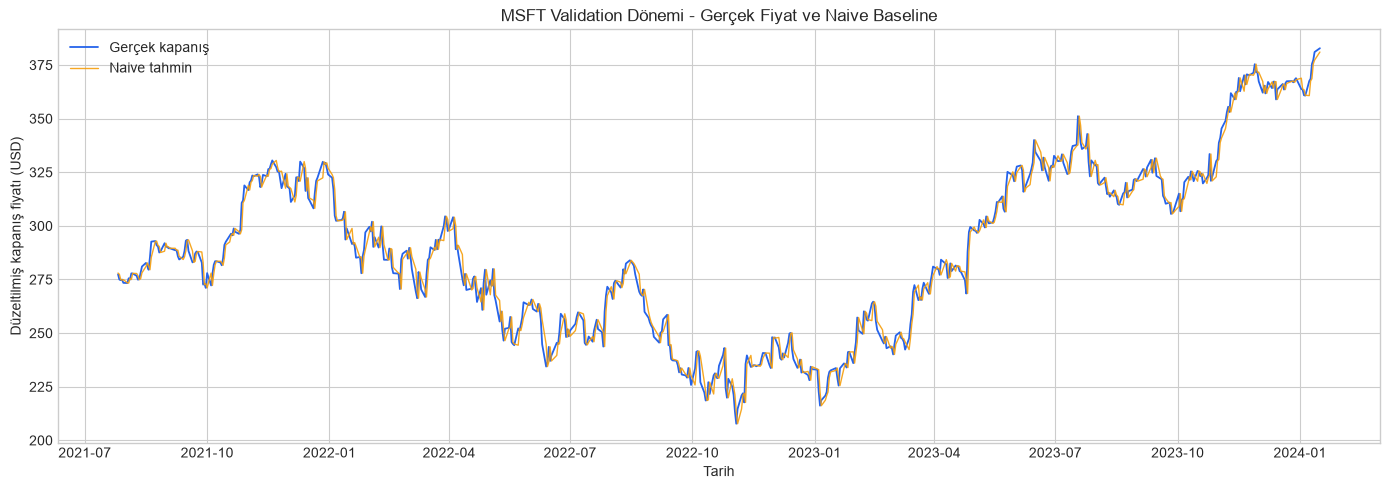

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    validation_baseline.index,
    validation_baseline["Actual"],
    label="Gerçek kapanış",
    color="#2563EB",
    linewidth=1.3,
)
ax.plot(
    validation_baseline.index,
    validation_baseline["Naive_Prediction"],
    label="Naive tahmin",
    color="#F59E0B",
    linewidth=1,
    alpha=0.9,
)
ax.set(
    title="MSFT Validation Dönemi - Gerçek Fiyat ve Naive Baseline",
    xlabel="Tarih",
    ylabel="Düzeltilmiş kapanış fiyatı (USD)",
)
ax.legend()
fig.tight_layout()
plt.show()

## 9. Değerlendirme

- Train, validation ve test dönemleri birbirini kronolojik olarak takip eder.
- Gelecekteki validation ve test fiyatları model eğitimine karışmaz.
- MinMaxScaler yalnızca train dönemindeki fiyat sınırlarını öğrenir.
- Validation ve test verileri aynı dönüşümle ölçeklenir; gelecekteki fiyatlar scaler fit işlemine katılmaz.
- Validation veya test değerlerinin `[-1, 1]` dışına çıkması beklenen ve bilgi taşıyan bir durumdur.
- Ters dönüşüm kontrolleri ölçeklenmiş değerlerden orijinal fiyatların geri alınabildiğini doğrular.
- Her giriş dizisi 20 geçmiş işlem günü ve tek özellik içerir.
- Set üyeliği hedef tarihine göre belirlenir; target tarihleri setler arasında kesişmez.
- Validation ve test dönemleri ilk günlerinden itibaren değerlendirilebilir; önceki dönemin son 20 günü yalnızca geçmiş bağlamıdır.
- Tüm model girdileri `[örnek, 20, 1]`, hedefler `[örnek, 1]` biçimindedir.
- Tensorlar `float32` türündedir ve başlangıçta CPU üzerinde tutulur.
- NumPy dizileriyle tensor değerlerinin birebir aynı olduğu doğrulanmıştır.
- Naive baseline validation döneminde bir önceki kapanışı tahmin olarak kullanır.
- Baseline metrikleri orijinal USD ölçeğinde hesaplanır ve model sonuçları için alt referans oluşturur.
- Test hedefleri baseline hesabına dahil edilmemiştir.